1. **Data preprocessing**  
   - Load probe voltage $V_\text{probe}$ and current $I_\text{probe}$ from the raw acquisition file.  
   - Apply an $n=4$ moving average to reduce high-frequency noise.  
   - Sort the data by voltage to obtain a clean monotonic I–V curve.

2. **Floating potential $V_f$**  
   - Locate the zero crossing of the total current $I(V)$ by either detecting a sign change or, if absent, taking the point of minimum $|I|$.  
   - Linearly interpolate between the two points bracketing $I=0$ to estimate $V_f$ with sub-sample precision.

3. **Ion current and subtraction**  
   - Define an ion-collection region at negative bias, $V < 0.9\,V_f$, where the probe collects mainly ions.  
   - Fit a straight line $I_\text{ion}(V) = a V + b$ to this region to model the ion current.  
   - Subtract this fit from the total current to obtain the electron current:
     $I_e(V) = I_\text{total}(V) - I_\text{ion}(V)$.

4. **Plasma potential $V_p$**  
   - Restrict to the electron-collection side $V > V_f$ and compute the numerical derivative $\mathrm{d}I_e/\mathrm{d}V$.  
   - Smooth $\mathrm{d}I_e/\mathrm{d}V$ with another $n=4$ moving average and identify its maximum.  
   - The voltage at which $\mathrm{d}I_e/\mathrm{d}V$ peaks is taken as the plasma potential $V_p$.

5. **Electron temperature $T_e$**  
   - Select only the steep exponential region of the electron current, e.g. $V_\text{start} \lesssim V \lesssim V_\text{end}$ (around the knee but below saturation).  
   - In this region, the electron current follows
     $$
     I_e(V) \propto \exp\!\left(\frac{e V}{k_B T_e}\right),
     $$
     so that $\ln I_e$ is approximately linear in $V$.  
   - Fit a line $\ln I_e = m V + c$ over the chosen interval and derive the effective electron temperature from the slope:
     $$
     k_B T_e = \frac{e}{m}, \qquad T_e = \frac{e}{m k_B},
     $$
     where $e$ is the elementary charge and $k_B$ is Boltzmann’s constant.  
   - Compute the coefficient of determination $R^2$ to quantify how well the exponential model describes the data in the selected region.


Smoothed data points: 432
>>> Vf = 12.1295 V
Ion current fit: I_ion = 1.296e-07·V + -1.518e-06
Electron current computed: Ie = I_total - I_ion_fit
>>> Vp = 41.2405 V
Fit region: 29.09 V to 32.99 V
Number of points: 20
>>> kTe = 0.4779 eV, Te = 5547.7 K, R² = 0.9178
Slope = 2.0925, Intercept = -81.7770
Measured saturation region: 44.37–79.41 V
Average measured Ie_sat = 1.262e-04 A
>>> Ie_sat (measured) = 1.262e-04 A
>>> ne = 8.669e+11 m^-3
>>> ne = 8.669e+05 cm^-3

Plot created successfully!

FINAL RESULTS:
1. Vf = 12.1295 V
2. Vp = 41.2405 V
3. Ie,sat = 1.262e-04 A
4. kTe = 0.4779 eV (Te = 5547.7 K)
5. ne = 8.669e+11 m^-3


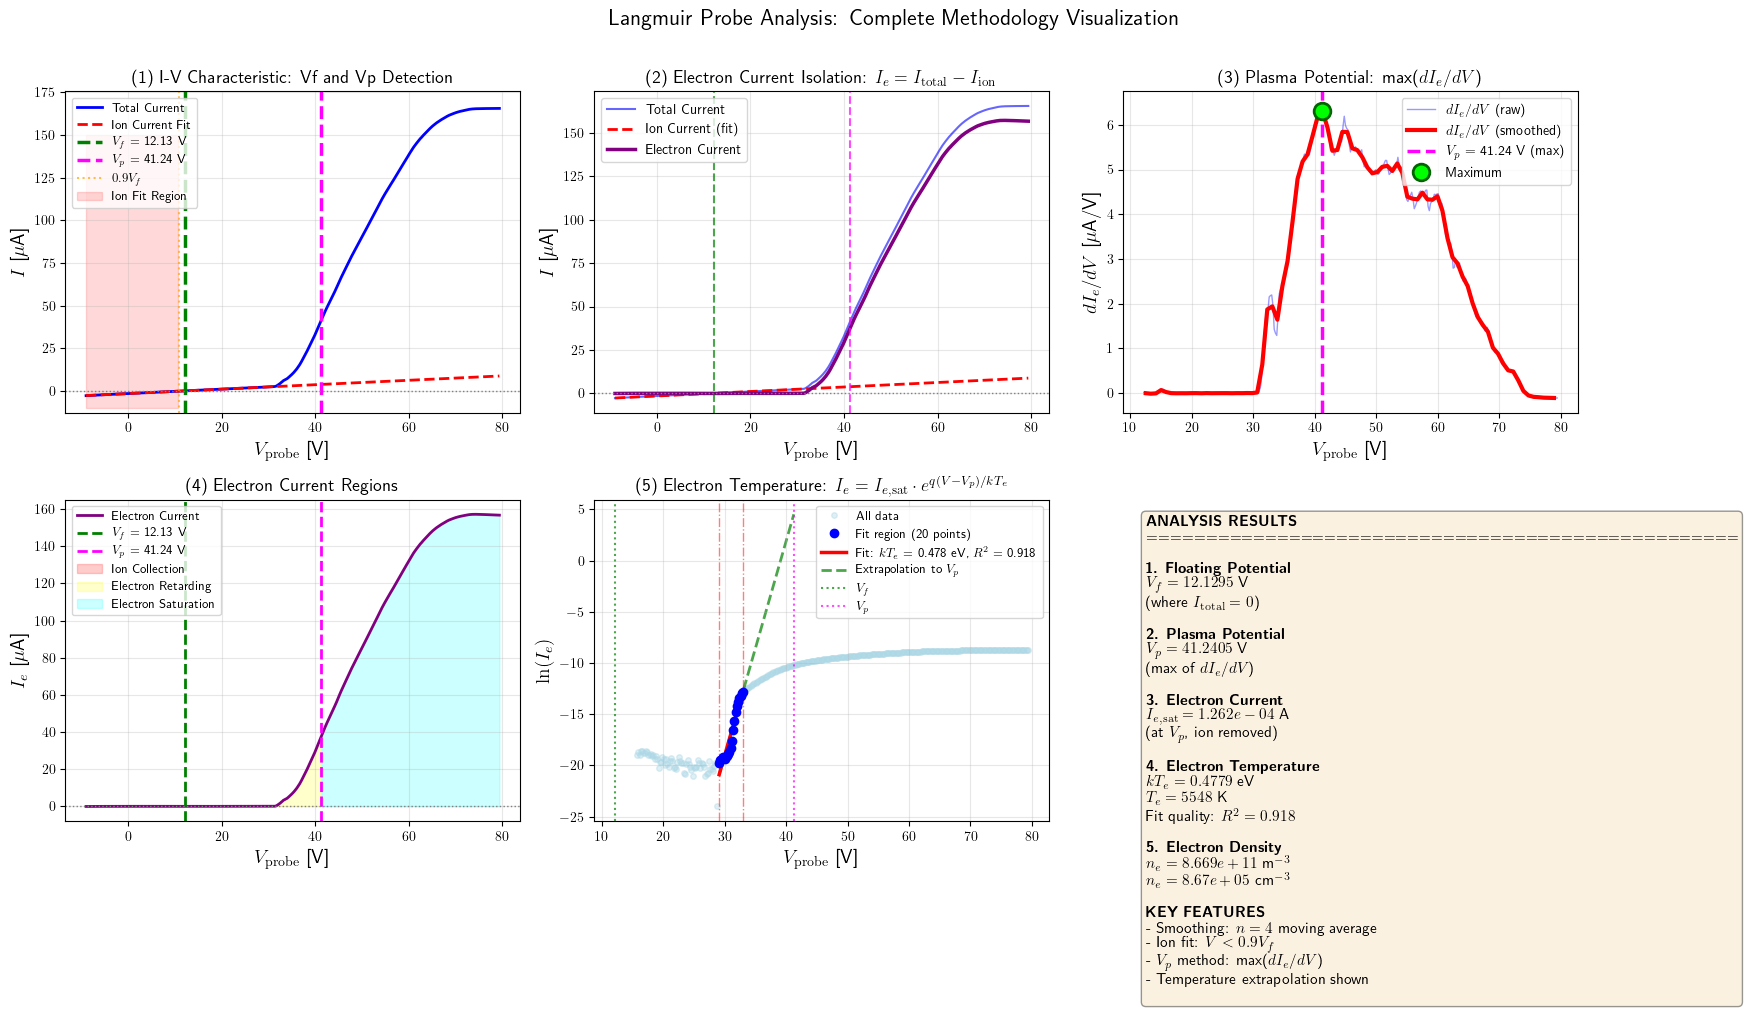

In [1]:

"""
Langmuir Probe Analysis - ENHANCED PLOTTING VERSION (FIXED)

"""

import numpy as np
import matplotlib.pyplot as plt
import scipy.io

plt.rcParams['text.usetex'] = True
plt.close('all')

# File loading

directory = "./"
name_file = "5A.csv"  # Change to your data file

if name_file[-3:] == 'mat':
    vector = scipy.io.loadmat(directory+name_file)
    readnum = vector['readNum']
    Vprobe = readnum[:,1][:int(len(readnum[:,1])/2)]
    Iprobe = readnum[:,2][:int(len(readnum[:,2])/2)]
elif name_file[-3:] == 'csv':
    vector = np.genfromtxt(directory+name_file, delimiter=';',
                          dtype=np.float32, skip_header=50, skip_footer=10, usecols=(0,1))
    Vprobe = vector[:,0]
    Iprobe = vector[:,1]


# STEP 0: SMOOTHING ( n=4 moving average)

n = 4  # Number of points to average
Imean = np.zeros(int(len(Iprobe)/n))
Vmean = np.zeros(int(len(Vprobe)/n))

for b in range(int(len(Vprobe)/n)):
    Imean[b] = np.sum(Iprobe[n*b:n*b+n])/n
    Vmean[b] = np.sum(Vprobe[n*b:n*b+n])/n

print(f"Smoothed data points: {len(Vmean)}")

# Use smoothed data
Vprobe = Vmean
Iprobe = Imean

# Constants

r = 2.5*1e-2      # probe radius, [m]
l = 5*1e-2        # probe length, [m]
me = 9.109*1e-31  # electron mass, [kg]
mi = 6.63*1e-26   # ion mass - Argon, [kg]
q = 1.602*1e-19   # electric charge, [C]
kb = 1.38*1e-23   # boltzmann constant, [J/K]
S = 4*np.pi*r**2  # probe surface area, [m^2]
Ap = S

# Sort by voltage
sort_idx = np.argsort(Vprobe)
V = Vprobe[sort_idx]
I = Iprobe[sort_idx]

# STEP 1: FLOATING POTENTIAL (Vf)


zero_crossings = np.where(np.diff(np.sign(I)))[0]

if len(zero_crossings) > 0:
    idx = zero_crossings[0]
    V1, V2 = V[idx], V[idx+1]
    I1, I2 = I[idx], I[idx+1]
    Vf = V1 - I1 * (V2 - V1) / (I2 - I1)
else:
    idx = np.argmin(np.abs(I))
    Vf = V[idx]

print(f">>> Vf = {Vf:.4f} V")

# STEP 2: ION CURRENT - LINEAR FIT (V < 0.9·Vf)


# Ion fit region
ion_region_mask = V < (0.9* Vf)
V_ion = V[ion_region_mask]
I_ion = I[ion_region_mask]

if len(V_ion) > 5:
    coeffs = np.polyfit(V_ion, I_ion, 1)
    slope_ion = coeffs[0]
    intercept_ion = coeffs[1]
    I_ion_fit = slope_ion * V + intercept_ion
    print(f"Ion current fit: I_ion = {slope_ion:.3e}·V + {intercept_ion:.3e}")
else:
    I_ion_fit = np.full_like(V, np.median(I_ion))

# STEP 3: ELECTRON CURRENT

Ie = I - I_ion_fit
print(f"Electron current computed: Ie = I_total - I_ion_fit")


# STEP 4: PLASMA POTENTIAL (Vp from dIe/dV)


# Focus on V > Vf
mask_pos = V > Vf
V_pos = V[mask_pos]
Ie_pos = Ie[mask_pos]

# Derivative
dIe_dV = np.gradient(Ie_pos, V_pos)

# Smooth derivative with n=4
n_smooth = 4
if len(dIe_dV) > n_smooth:
    dIe_dV_smooth = np.zeros(int(len(dIe_dV)/n_smooth))
    V_pos_smooth = np.zeros(int(len(V_pos)/n_smooth))

    for b in range(int(len(dIe_dV)/n_smooth)):
        dIe_dV_smooth[b] = np.sum(dIe_dV[n_smooth*b:n_smooth*b+n_smooth])/n_smooth
        V_pos_smooth[b] = np.sum(V_pos[n_smooth*b:n_smooth*b+n_smooth])/n_smooth

    idx_max = np.argmax(dIe_dV_smooth)
    Vp = V_pos_smooth[idx_max]
else:
    dIe_dV_smooth = dIe_dV
    V_pos_smooth = V_pos
    idx_max = np.argmax(dIe_dV)
    Vp = V_pos[idx_max]

print(f">>> Vp = {Vp:.4f} V")


# STEP 5: ELECTRON TEMPERATURE



V_start = 29.0# Start of steep exponential rise
V_end = 33.0    # End of steep rise (just before saturation)

# Apply strict mask - ONLY the steep region
ret_mask = (V >= V_start) & (V <= V_end)
V_ret = V[ret_mask]
Ie_ret = Ie[ret_mask]

# Positive currents only
pos_mask = Ie_ret > 0
V_fit = V_ret[pos_mask]
Ie_fit = Ie_ret[pos_mask]

print(f"Fit region: {V_fit.min():.2f} V to {V_fit.max():.2f} V")
print(f"Number of points: {len(V_fit)}")

if len(V_fit) > 5:
    ln_Ie = np.log(Ie_fit)
    slope, intercept = np.polyfit(V_fit, ln_Ie, 1)

    kTe_J = q / slope
    Te_K = kTe_J / kb
    kTe_eV = kTe_J / q

    # R² calculation
    ln_Ie_pred = slope * V_fit + intercept
    residuals = ln_Ie - ln_Ie_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((ln_Ie - np.mean(ln_Ie))**2)
    r_squared = 1 - (ss_res / ss_tot)

    print(f">>> kTe = {kTe_eV:.4f} eV, Te = {Te_K:.1f} K, R² = {r_squared:.4f}")
    print(f"Slope = {slope:.4f}, Intercept = {intercept:.4f}")

    # Create extrapolation line for visualization
    V_extrap = np.linspace(V_fit.min(), Vp, 100)
    Ie_extrap = np.exp(slope * V_extrap + intercept)
else:
    print("WARNING: Not enough points in fit region!")
    kTe_eV = 0.5
    Te_K = kTe_eV * 11604
    r_squared = 0
    V_extrap = np.array([])
    Ie_extrap = np.array([])



# STEP 6: ELECTRON DENSITY (USING MEASURED CURRENT)


# Correct probe collection area (cylindrical probe)
Ap = 2 * np.pi * r * l   # [m^2]

# 1) Choose a measured saturation current region:
#    V > Vp + ΔV, where Ie is flat (electron saturation)
DeltaV_sat = 3.0  # volts above Vp (adjust if needed)

sat_mask = (V >= Vp + DeltaV_sat) & (Ie > 0)
if np.sum(sat_mask) < 3:
    print("WARNING: Not enough points in measured saturation region, "
          "falling back to extrapolated current.")
    Ie_sat_meas = np.exp(slope * Vp + intercept)
else:
    # Use the mean of Ie in the saturation region
    Ie_sat_meas = np.mean(Ie[sat_mask])
    print(f"Measured saturation region: {V[sat_mask].min():.2f}–{V[sat_mask].max():.2f} V")
    print(f"Average measured Ie_sat = {Ie_sat_meas:.3e} A")

# 2) Use this measured Ie_sat in the density formula
Ie_sat = Ie_sat_meas  # for consistency with later printing

# Electron temperature in Joules (from fit)
kTe_J = kTe_eV * q

# Electron density
ne = (Ie_sat / (q * Ap)) * np.sqrt((2 * np.pi * me) / kTe_J)

print(f">>> Ie_sat (measured) = {Ie_sat:.3e} A")
print(f">>> ne = {ne:.3e} m^-3")
print(f">>> ne = {ne/1e6:.3e} cm^-3")



fig = plt.figure(figsize=(18, 10))

# Create a 2x3 grid
# Plot 1: Main I-V curve with ALL key points marked
ax1 = plt.subplot(2, 3, 1)
ax1.plot(V, I*1e6, 'b-', linewidth=2, label='Total Current')
ax1.plot(V, I_ion_fit*1e6, 'r--', linewidth=2, label='Ion Current Fit')
ax1.axvline(x=Vf, color='green', linestyle='--', linewidth=2.5, label=f'$V_f$ = {Vf:.2f} V')
ax1.axvline(x=Vp, color='magenta', linestyle='--', linewidth=2.5, label=f'$V_p$ = {Vp:.2f} V')
ax1.axvline(x=0.9*Vf, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=r'$0.9 V_f$')
ax1.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax1.fill_between(V[ion_region_mask], -10, 150, alpha=0.15, color='red', label='Ion Fit Region')
ax1.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax1.set_ylabel(r'$I$ [$\mu$A]', fontsize=14)
ax1.set_title('(1) I-V Characteristic: Vf and Vp Detection', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([I.min()*1e6-10, I.max()*1e6+10])

# Plot 2: Electron current isolation
ax2 = plt.subplot(2, 3, 2)
ax2.plot(V, I*1e6, 'b-', linewidth=1.5, alpha=0.6, label='Total Current')
ax2.plot(V, I_ion_fit*1e6, 'r--', linewidth=2, label='Ion Current (fit)')
ax2.plot(V, Ie*1e6, 'purple', linewidth=2.5, label='Electron Current')
ax2.axvline(x=Vf, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axvline(x=Vp, color='magenta', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax2.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax2.set_ylabel(r'$I$ [$\mu$A]', fontsize=14)
ax2.set_title(r'(2) Electron Current Isolation: $I_e = I_{\mathrm{total}} - I_{\mathrm{ion}}$', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: dIe/dV for Vp detection
ax3 = plt.subplot(2, 3, 3)
ax3.plot(V_pos, dIe_dV*1e6, 'b-', alpha=0.4, linewidth=1, label='$dI_e/dV$ (raw)')
ax3.plot(V_pos_smooth, dIe_dV_smooth*1e6, 'r-', linewidth=3, label='$dI_e/dV$ (smoothed)')
ax3.axvline(x=Vp, color='magenta', linestyle='--', linewidth=2.5, label=f'$V_p$ = {Vp:.2f} V (max)')
ax3.plot(Vp, dIe_dV_smooth[idx_max]*1e6, 'go', markersize=12, markeredgewidth=2, 
         markerfacecolor='lime', markeredgecolor='darkgreen', label='Maximum', zorder=5)
ax3.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax3.set_ylabel(r'$dI_e/dV$ [$\mu$A/V]', fontsize=14)
ax3.set_title('(3) Plasma Potential: max($dI_e/dV$)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Electron current with regions marked
ax4 = plt.subplot(2, 3, 4)
ax4.plot(V, Ie*1e6, 'purple', linewidth=2, label='Electron Current')
ax4.axvline(x=Vf, color='green', linestyle='--', linewidth=2, label=f'$V_f$ = {Vf:.2f} V')
ax4.axvline(x=Vp, color='magenta', linestyle='--', linewidth=2, label=f'$V_p$ = {Vp:.2f} V')
# Mark regions
ax4.fill_between(V[V<Vf], 0, Ie[V<Vf]*1e6, alpha=0.2, color='red', label='Ion Collection')
ax4.fill_between(V[(V>=Vf)&(V<=Vp)], 0, Ie[(V>=Vf)&(V<=Vp)]*1e6, alpha=0.2, 
                 color='yellow', label='Electron Retarding')
ax4.fill_between(V[V>Vp], 0, Ie[V>Vp]*1e6, alpha=0.2, color='cyan', label='Electron Saturation')
ax4.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax4.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax4.set_ylabel(r'$I_e$ [$\mu$A]', fontsize=14)
ax4.set_title('(4) Electron Current Regions', fontsize=13, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
# Plot 5: Temperature fit with extrapolation
ax5 = plt.subplot(2, 3, 5)

# **SHOW ALL DATA** (not just fit region)
# Filter for positive electron current across all voltages
mask_all_positive = (V > Vf) & (Ie > 0)
V_all_plot = V[mask_all_positive]
Ie_all_plot = Ie[mask_all_positive]
ln_Ie_all_plot = np.log(Ie_all_plot)
# Plot ALL points in gray/light color
ax5.plot(V_all_plot, ln_Ie_all_plot, 'o', color='lightblue', 
         markersize=4, alpha=0.4, label='All data', zorder=1)

if len(V_fit) > 5:
    # Highlight FIT REGION points in blue
    ax5.plot(V_fit, ln_Ie, 'bo', markersize=6, 
             label=f'Fit region ({len(V_fit)} points)', zorder=3)
    
    # Plot the fit line
    ax5.plot(V_fit, ln_Ie_pred, 'r-', linewidth=2.5, 
             label=f'Fit: $kT_e$ = {kTe_eV:.3f} eV, $R^2$ = {r_squared:.3f}', zorder=2)
    
    # Extrapolation line
    ax5.plot(V_extrap, slope*V_extrap+intercept, 'g--', linewidth=2, 
             alpha=0.7, label='Extrapolation to $V_p$', zorder=1)
    
    ax5.axvline(x=Vf, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label='$V_f$')
    ax5.axvline(x=Vp, color='magenta', linestyle=':', linewidth=1.5, alpha=0.7, label='$V_p$')
    
    # Mark the fit region boundaries
    ax5.axvline(x=V_start, color='red', linestyle='-.', linewidth=1, alpha=0.5)
    ax5.axvline(x=V_end, color='red', linestyle='-.', linewidth=1, alpha=0.5)

ax5.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax5.set_ylabel(r'$\ln(I_e)$', fontsize=14)
ax5.set_title(r'(5) Electron Temperature: $I_e = I_{e,\mathrm{sat}} \cdot e^{q(V-V_p)/kT_e}$', 
              fontsize=13, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)



# Plot 6: Summary with key results
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

# FIXED: Use raw strings and avoid Python variable interpolation inside LaTeX
summary_text = r"""\textbf{ANALYSIS RESULTS}
""" + f"""{'='*50}

""" + r"""\textbf{1. Floating Potential}
""" + f"""   $V_f = {Vf:.4f}$ V
   (where $I_{{\mathrm{{total}}}} = 0$)

""" + r"""\textbf{2. Plasma Potential}
""" + f"""   $V_p = {Vp:.4f}$ V
   (max of $dI_e/dV$)

""" + r"""\textbf{3. Electron Current}
""" + f"""   $I_{{e,\mathrm{{sat}}}} = {Ie_sat:.3e}$ A
   (at $V_p$, ion removed)

""" + r"""\textbf{4. Electron Temperature}
""" + f"""   $kT_e = {kTe_eV:.4f}$ eV
   $T_e = {Te_K:.0f}$ K
   Fit quality: $R^2 = {r_squared:.3f}$

""" + r"""\textbf{5. Electron Density}
""" + f"""   $n_e = {ne:.3e}$ m$^{{-3}}$
   $n_e = {ne/1e6:.2e}$ cm$^{{-3}}$

""" + r"""\textbf{KEY FEATURES}
""" + f"""- Smoothing: $n=4$ moving average
- Ion fit: $V < 0.9 V_f$
- $V_p$ method: max($dI_e/dV$)
- Temperature extrapolation shown
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.suptitle('Langmuir Probe Analysis: Complete Methodology Visualization', 
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])

print("\nPlot created successfully!")
print("\nFINAL RESULTS:")
print("="*80)
print(f"1. Vf = {Vf:.4f} V")
print(f"2. Vp = {Vp:.4f} V")
print(f"3. Ie,sat = {Ie_sat:.3e} A")
print(f"4. kTe = {kTe_eV:.4f} eV (Te = {Te_K:.1f} K)")
print(f"5. ne = {ne:.3e} m^-3")
print("="*80)

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


LANGMUIR PROBE ANALYSIS - COMPREHENSIVE VISUALIZATION
Original data points: 1730
Smoothed data points: 432
>>> Vf = 29.0432 V
Ion current fit: I_ion = 3.390e-07·V + -1.265e-05
Electron current computed: Ie = I_total - I_ion_fit
>>> Vp = 40.5539 V
Fit region: 30.94 V to 31.93 V
Number of points: 6
>>> kTe = 1.8641 eV, Te = 21640.3 K, R² = 0.9965
Slope = 0.5364, Intercept = -27.5268
Measured saturation region: 43.68–79.41 V
Average measured Ie_sat = 1.576e-04 A
>>> Ie_sat (measured) = 1.576e-04 A
>>> ne = 5.483e+11 m^-3
>>> ne = 5.483e+05 cm^-3

Plot created successfully!

FINAL RESULTS:
1. Vf = 29.0432 V
2. Vp = 40.5539 V
3. Ie,sat = 1.576e-04 A
4. kTe = 1.8641 eV (Te = 21640.3 K)
5. ne = 5.483e+11 m^-3


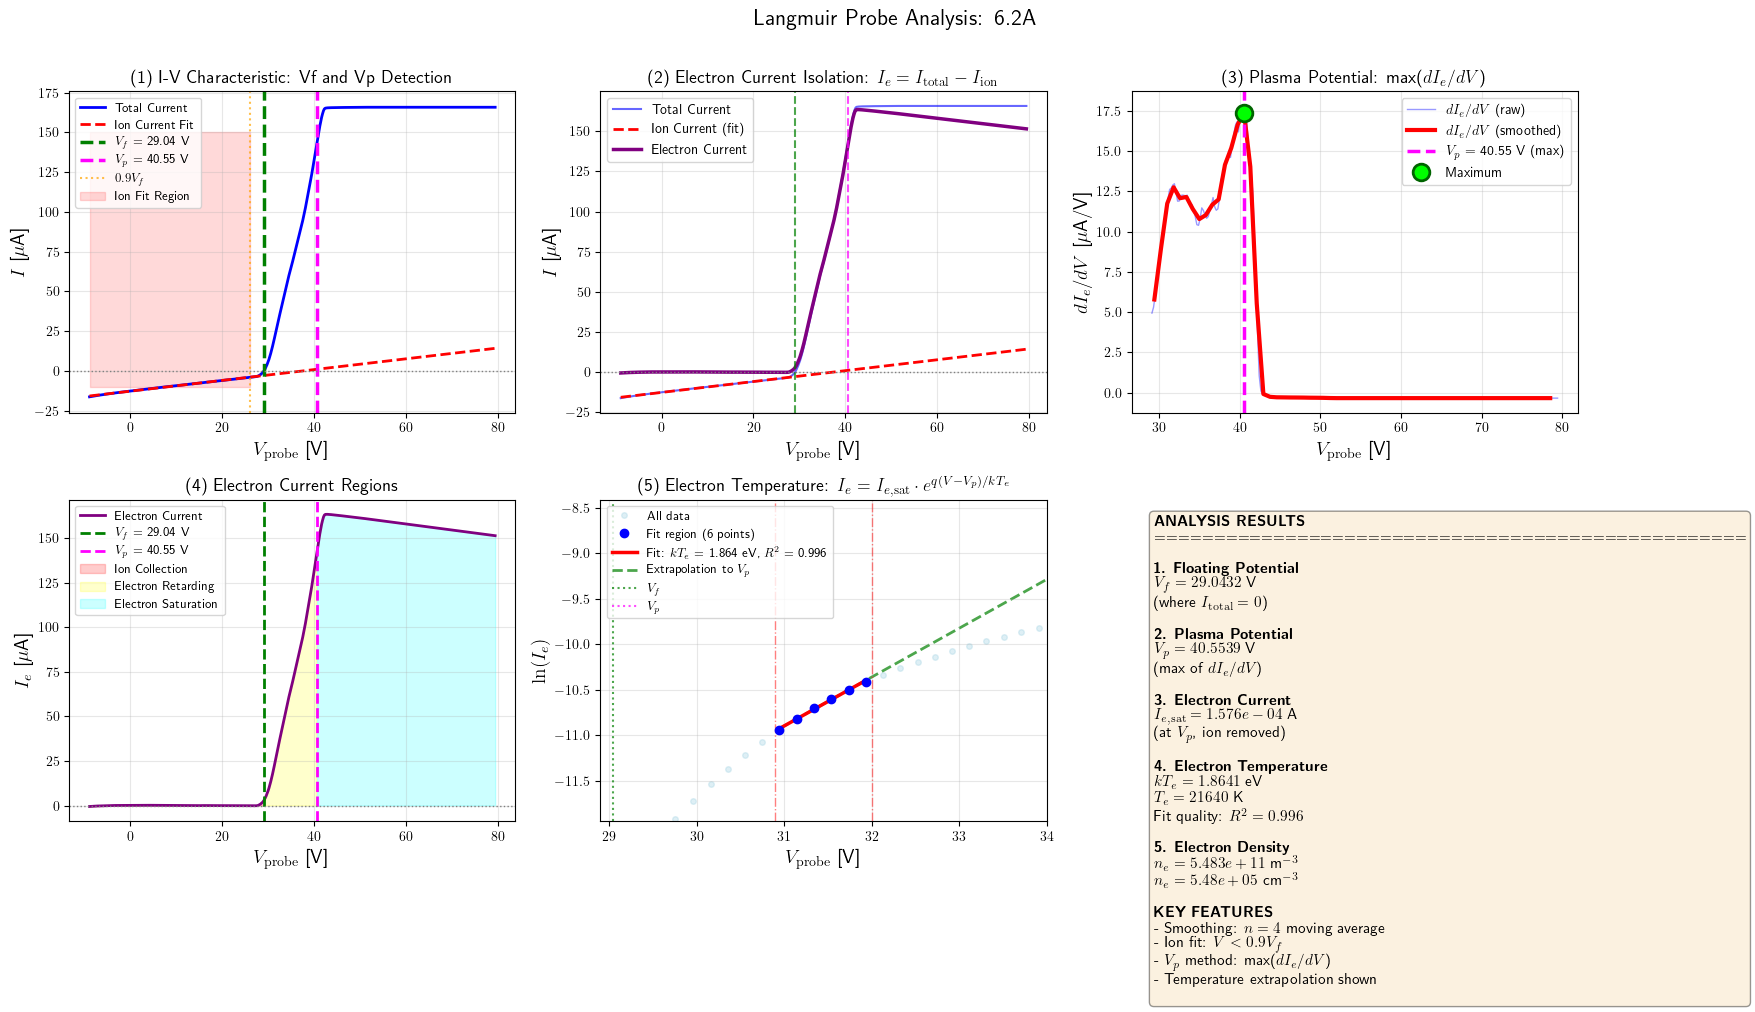

In [2]:

"""
Langmuir Probe Analysis - ENHANCED PLOTTING VERSION (FIXED)
Shows all 5 analysis steps clearly marked and annotated
Based on instructor's methodology
"""

import numpy as np
import matplotlib.pyplot as plt
import scipy.io

plt.rcParams['text.usetex'] = True
plt.close('all')

directory = "./"
name_file = "6.2A.csv"  # Change to your data file

if name_file[-3:] == 'mat':
    vector = scipy.io.loadmat(directory+name_file)
    readnum = vector['readNum']
    Vprobe = readnum[:,1][:int(len(readnum[:,1])/2)]
    Iprobe = readnum[:,2][:int(len(readnum[:,2])/2)]
elif name_file[-3:] == 'csv':
    vector = np.genfromtxt(directory+name_file, delimiter=';',
                          dtype=np.float32, skip_header=50, skip_footer=10, usecols=(0,1))
    Vprobe = vector[:,0]
    Iprobe = vector[:,1]

print("="*80)
print("LANGMUIR PROBE ANALYSIS - COMPREHENSIVE VISUALIZATION")
print("="*80)
print(f"Original data points: {len(Vprobe)}")


n = 4  # Number of points to average
Imean = np.zeros(int(len(Iprobe)/n))
Vmean = np.zeros(int(len(Vprobe)/n))

for b in range(int(len(Vprobe)/n)):
    Imean[b] = np.sum(Iprobe[n*b:n*b+n])/n
    Vmean[b] = np.sum(Vprobe[n*b:n*b+n])/n

print(f"Smoothed data points: {len(Vmean)}")

# Use smoothed data
Vprobe = Vmean
Iprobe = Imean

r = 2.5*1e-2      # probe radius, [m]
l = 5*1e-2        # probe length, [m]
me = 9.109*1e-31  # electron mass, [kg]
mi = 6.63*1e-26   # ion mass - Argon, [kg]
q = 1.602*1e-19   # electric charge, [C]
kb = 1.38*1e-23   # boltzmann constant, [J/K]
S = 4*np.pi*r**2  # probe surface area, [m^2]
Ap = S

# Sort by voltage
sort_idx = np.argsort(Vprobe)
V = Vprobe[sort_idx]
I = Iprobe[sort_idx]



zero_crossings = np.where(np.diff(np.sign(I)))[0]

if len(zero_crossings) > 0:
    idx = zero_crossings[0]
    V1, V2 = V[idx], V[idx+1]
    I1, I2 = I[idx], I[idx+1]
    Vf = V1 - I1 * (V2 - V1) / (I2 - I1)
else:
    idx = np.argmin(np.abs(I))
    Vf = V[idx]

print(f">>> Vf = {Vf:.4f} V")


# Ion fit region
ion_region_mask = V < (0.9* Vf)
V_ion = V[ion_region_mask]
I_ion = I[ion_region_mask]

if len(V_ion) > 5:
    coeffs = np.polyfit(V_ion, I_ion, 1)
    slope_ion = coeffs[0]
    intercept_ion = coeffs[1]
    I_ion_fit = slope_ion * V + intercept_ion
    print(f"Ion current fit: I_ion = {slope_ion:.3e}·V + {intercept_ion:.3e}")
else:
    I_ion_fit = np.full_like(V, np.median(I_ion))


Ie = I - I_ion_fit
print(f"Electron current computed: Ie = I_total - I_ion_fit")


# Focus on V > Vf
mask_pos = V > Vf
V_pos = V[mask_pos]
Ie_pos = Ie[mask_pos]

# Derivative
dIe_dV = np.gradient(Ie_pos, V_pos)

# Smooth derivative with n=4
n_smooth = 4
if len(dIe_dV) > n_smooth:
    dIe_dV_smooth = np.zeros(int(len(dIe_dV)/n_smooth))
    V_pos_smooth = np.zeros(int(len(V_pos)/n_smooth))

    for b in range(int(len(dIe_dV)/n_smooth)):
        dIe_dV_smooth[b] = np.sum(dIe_dV[n_smooth*b:n_smooth*b+n_smooth])/n_smooth
        V_pos_smooth[b] = np.sum(V_pos[n_smooth*b:n_smooth*b+n_smooth])/n_smooth

    idx_max = np.argmax(dIe_dV_smooth)
    Vp = V_pos_smooth[idx_max]
else:
    dIe_dV_smooth = dIe_dV
    V_pos_smooth = V_pos
    idx_max = np.argmax(dIe_dV)
    Vp = V_pos[idx_max]

print(f">>> Vp = {Vp:.4f} V")



V_start = 30.9# Start of steep exponential rise
V_end = 32.0    # End of steep rise (just before saturation)

# Apply strict mask - ONLY the steep region
ret_mask = (V >= V_start) & (V <= V_end)
V_ret = V[ret_mask]
Ie_ret = Ie[ret_mask]

# Positive currents only
pos_mask = Ie_ret > 0
V_fit = V_ret[pos_mask]
Ie_fit = Ie_ret[pos_mask]

print(f"Fit region: {V_fit.min():.2f} V to {V_fit.max():.2f} V")
print(f"Number of points: {len(V_fit)}")

if len(V_fit) > 5:
    ln_Ie = np.log(Ie_fit)
    slope, intercept = np.polyfit(V_fit, ln_Ie, 1)

    kTe_J = q / slope
    Te_K = kTe_J / kb
    kTe_eV = kTe_J / q

    # R² calculation
    ln_Ie_pred = slope * V_fit + intercept
    residuals = ln_Ie - ln_Ie_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((ln_Ie - np.mean(ln_Ie))**2)
    r_squared = 1 - (ss_res / ss_tot)

    print(f">>> kTe = {kTe_eV:.4f} eV, Te = {Te_K:.1f} K, R² = {r_squared:.4f}")
    print(f"Slope = {slope:.4f}, Intercept = {intercept:.4f}")

    # Create extrapolation line for visualization
    V_extrap = np.linspace(V_fit.min(), Vp, 100)
    Ie_extrap = np.exp(slope * V_extrap + intercept)
else:
    print("WARNING: Not enough points in fit region!")
    kTe_eV = 0.5
    Te_K = kTe_eV * 11604
    r_squared = 0
    V_extrap = np.array([])
    Ie_extrap = np.array([])



# Correct probe collection area (cylindrical probe)
Ap = 2 * np.pi * r * l   # [m^2]

# 1) Choose a measured saturation current region:
#    V > Vp + ΔV, where Ie is flat (electron saturation)
DeltaV_sat = 3.0  # volts above Vp (adjust if needed)

sat_mask = (V >= Vp + DeltaV_sat) & (Ie > 0)
if np.sum(sat_mask) < 3:
    print("WARNING: Not enough points in measured saturation region, "
          "falling back to extrapolated current.")
    Ie_sat_meas = np.exp(slope * Vp + intercept)
else:
    # Use the mean of Ie in the saturation region
    Ie_sat_meas = np.mean(Ie[sat_mask])
    print(f"Measured saturation region: {V[sat_mask].min():.2f}–{V[sat_mask].max():.2f} V")
    print(f"Average measured Ie_sat = {Ie_sat_meas:.3e} A")

# 2) Use this measured Ie_sat in the density formula
Ie_sat = Ie_sat_meas  # for consistency with later printing

# Electron temperature in Joules (from fit)
kTe_J = kTe_eV * q

# Electron density
ne = (Ie_sat / (q * Ap)) * np.sqrt((2 * np.pi * me) / kTe_J)

print(f">>> Ie_sat (measured) = {Ie_sat:.3e} A")
print(f">>> ne = {ne:.3e} m^-3")
print(f">>> ne = {ne/1e6:.3e} cm^-3")





fig = plt.figure(figsize=(18, 10))

# Create a 2x3 grid
# Plot 1: Main I-V curve with ALL key points marked
ax1 = plt.subplot(2, 3, 1)
ax1.plot(V, I*1e6, 'b-', linewidth=2, label='Total Current')
ax1.plot(V, I_ion_fit*1e6, 'r--', linewidth=2, label='Ion Current Fit')
ax1.axvline(x=Vf, color='green', linestyle='--', linewidth=2.5, label=f'$V_f$ = {Vf:.2f} V')
ax1.axvline(x=Vp, color='magenta', linestyle='--', linewidth=2.5, label=f'$V_p$ = {Vp:.2f} V')
ax1.axvline(x=0.9*Vf, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=r'$0.9 V_f$')
ax1.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax1.fill_between(V[ion_region_mask], -10, 150, alpha=0.15, color='red', label='Ion Fit Region')
ax1.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax1.set_ylabel(r'$I$ [$\mu$A]', fontsize=14)
ax1.set_title('(1) I-V Characteristic: Vf and Vp Detection', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([I.min()*1e6-10, I.max()*1e6+10])

# Plot 2: Electron current isolation
ax2 = plt.subplot(2, 3, 2)
ax2.plot(V, I*1e6, 'b-', linewidth=1.5, alpha=0.6, label='Total Current')
ax2.plot(V, I_ion_fit*1e6, 'r--', linewidth=2, label='Ion Current (fit)')
ax2.plot(V, Ie*1e6, 'purple', linewidth=2.5, label='Electron Current')
ax2.axvline(x=Vf, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axvline(x=Vp, color='magenta', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax2.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax2.set_ylabel(r'$I$ [$\mu$A]', fontsize=14)
ax2.set_title(r'(2) Electron Current Isolation: $I_e = I_{\mathrm{total}} - I_{\mathrm{ion}}$', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: dIe/dV for Vp detection
ax3 = plt.subplot(2, 3, 3)
ax3.plot(V_pos, dIe_dV*1e6, 'b-', alpha=0.4, linewidth=1, label='$dI_e/dV$ (raw)')
ax3.plot(V_pos_smooth, dIe_dV_smooth*1e6, 'r-', linewidth=3, label='$dI_e/dV$ (smoothed)')
ax3.axvline(x=Vp, color='magenta', linestyle='--', linewidth=2.5, label=f'$V_p$ = {Vp:.2f} V (max)')
ax3.plot(Vp, dIe_dV_smooth[idx_max]*1e6, 'go', markersize=12, markeredgewidth=2, 
         markerfacecolor='lime', markeredgecolor='darkgreen', label='Maximum', zorder=5)
ax3.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax3.set_ylabel(r'$dI_e/dV$ [$\mu$A/V]', fontsize=14)
ax3.set_title('(3) Plasma Potential: max($dI_e/dV$)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Electron current with regions marked
ax4 = plt.subplot(2, 3, 4)
ax4.plot(V, Ie*1e6, 'purple', linewidth=2, label='Electron Current')
ax4.axvline(x=Vf, color='green', linestyle='--', linewidth=2, label=f'$V_f$ = {Vf:.2f} V')
ax4.axvline(x=Vp, color='magenta', linestyle='--', linewidth=2, label=f'$V_p$ = {Vp:.2f} V')
# Mark regions
ax4.fill_between(V[V<Vf], 0, Ie[V<Vf]*1e6, alpha=0.2, color='red', label='Ion Collection')
ax4.fill_between(V[(V>=Vf)&(V<=Vp)], 0, Ie[(V>=Vf)&(V<=Vp)]*1e6, alpha=0.2, 
                 color='yellow', label='Electron Retarding')
ax4.fill_between(V[V>Vp], 0, Ie[V>Vp]*1e6, alpha=0.2, color='cyan', label='Electron Saturation')
ax4.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax4.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax4.set_ylabel(r'$I_e$ [$\mu$A]', fontsize=14)
ax4.set_title('(4) Electron Current Regions', fontsize=13, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
# Plot 5: Temperature fit with extrapolation
ax5 = plt.subplot(2, 3, 5)
#################_______ZOOM___________################


ax5.set_xlim([V_start - 2, V_end + 2])  # Show 2V before and after fit region
ax5.set_ylim([ln_Ie.min() - 1, ln_Ie.max() + 2])  # Zoom y-axis to fit data

ax5.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax5.set_ylabel(r'$\ln(I_e)$', fontsize=14)
ax5.set_title(r'(5) Electron Temperature: $I_e = I_{e,\mathrm{sat}} \cdot e^{q(V-V_p)/kT_e}$', 
              fontsize=13, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# **SHOW ALL DATA** (not just fit region)
# Filter for positive electron current across all voltages
mask_all_positive = (V > Vf) & (Ie > 0)
V_all_plot = V[mask_all_positive]
Ie_all_plot = Ie[mask_all_positive]
ln_Ie_all_plot = np.log(Ie_all_plot)
# Plot ALL points in gray/light color
ax5.plot(V_all_plot, ln_Ie_all_plot, 'o', color='lightblue', 
         markersize=4, alpha=0.4, label='All data', zorder=1)

if len(V_fit) > 5:
    # Highlight FIT REGION points in blue
    ax5.plot(V_fit, ln_Ie, 'bo', markersize=6, 
             label=f'Fit region ({len(V_fit)} points)', zorder=3)
    
    # Plot the fit line
    ax5.plot(V_fit, ln_Ie_pred, 'r-', linewidth=2.5, 
             label=f'Fit: $kT_e$ = {kTe_eV:.3f} eV, $R^2$ = {r_squared:.3f}', zorder=2)
    
    # Extrapolation line
    ax5.plot(V_extrap, slope*V_extrap+intercept, 'g--', linewidth=2, 
             alpha=0.7, label='Extrapolation to $V_p$', zorder=1)
    
    ax5.axvline(x=Vf, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label='$V_f$')
    ax5.axvline(x=Vp, color='magenta', linestyle=':', linewidth=1.5, alpha=0.7, label='$V_p$')
    
    # Mark the fit region boundaries
    ax5.axvline(x=V_start, color='red', linestyle='-.', linewidth=1, alpha=0.5)
    ax5.axvline(x=V_end, color='red', linestyle='-.', linewidth=1, alpha=0.5)

ax5.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax5.set_ylabel(r'$\ln(I_e)$', fontsize=14)
ax5.set_title(r'(5) Electron Temperature: $I_e = I_{e,\mathrm{sat}} \cdot e^{q(V-V_p)/kT_e}$', 
              fontsize=13, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)



# Plot 6: Summary with key results
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

# FIXED: Use raw strings and avoid Python variable interpolation inside LaTeX
summary_text = r"""\textbf{ANALYSIS RESULTS}
""" + f"""{'='*50}

""" + r"""\textbf{1. Floating Potential}
""" + f"""   $V_f = {Vf:.4f}$ V
   (where $I_{{\mathrm{{total}}}} = 0$)

""" + r"""\textbf{2. Plasma Potential}
""" + f"""   $V_p = {Vp:.4f}$ V
   (max of $dI_e/dV$)

""" + r"""\textbf{3. Electron Current}
""" + f"""   $I_{{e,\mathrm{{sat}}}} = {Ie_sat:.3e}$ A
   (at $V_p$, ion removed)

""" + r"""\textbf{4. Electron Temperature}
""" + f"""   $kT_e = {kTe_eV:.4f}$ eV
   $T_e = {Te_K:.0f}$ K
   Fit quality: $R^2 = {r_squared:.3f}$

""" + r"""\textbf{5. Electron Density}
""" + f"""   $n_e = {ne:.3e}$ m$^{{-3}}$
   $n_e = {ne/1e6:.2e}$ cm$^{{-3}}$

""" + r"""\textbf{KEY FEATURES}
""" + f"""- Smoothing: $n=4$ moving average
- Ion fit: $V < 0.9 V_f$
- $V_p$ method: max($dI_e/dV$)
- Temperature extrapolation shown
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.suptitle('Langmuir Probe Analysis: 6.2A', 
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])

print("\nPlot created successfully!")
print("\nFINAL RESULTS:")
print("="*80)
print(f"1. Vf = {Vf:.4f} V")
print(f"2. Vp = {Vp:.4f} V")
print(f"3. Ie,sat = {Ie_sat:.3e} A")
print(f"4. kTe = {kTe_eV:.4f} eV (Te = {Te_K:.1f} K)")
print(f"5. ne = {ne:.3e} m^-3")
print("="*80)

plt.show()

In [3]:
# Use measured current from V > Vp + 3V
sat_mask = (V >= Vp + 3.0) & (Ie > 0)
Ie_sat = np.mean(Ie[sat_mask])


In [4]:
Ie_sat

0.00015757734813532127

Smoothed data points: 432
>>> Vf = 29.0432 V
Ion current fit: I_ion = 3.390e-07·V + -1.265e-05
Electron current computed: Ie = I_total - I_ion_fit
>>> Vp = 40.5539 V
Fit region: 30.94 V to 31.93 V
Number of points: 6
>>> kTe = 1.8641 eV, Te = 21640.3 K, R² = 0.9965
Slope = 0.5364, Intercept = -27.5268
Measured saturation region: 43.68–79.41 V
Average measured Ie_sat = 1.576e-04 A
>>> Ie_sat (measured) = 1.576e-04 A
>>> ne = 5.483e+11 m^-3
>>> ne = 5.483e+05 cm^-3

Plot created successfully!

FINAL RESULTS:
1. Vf = 29.0432 V
2. Vp = 40.5539 V
3. Ie,sat = 1.576e-04 A
4. kTe = 1.8641 eV (Te = 21640.3 K)
5. ne = 5.483e+11 m^-3


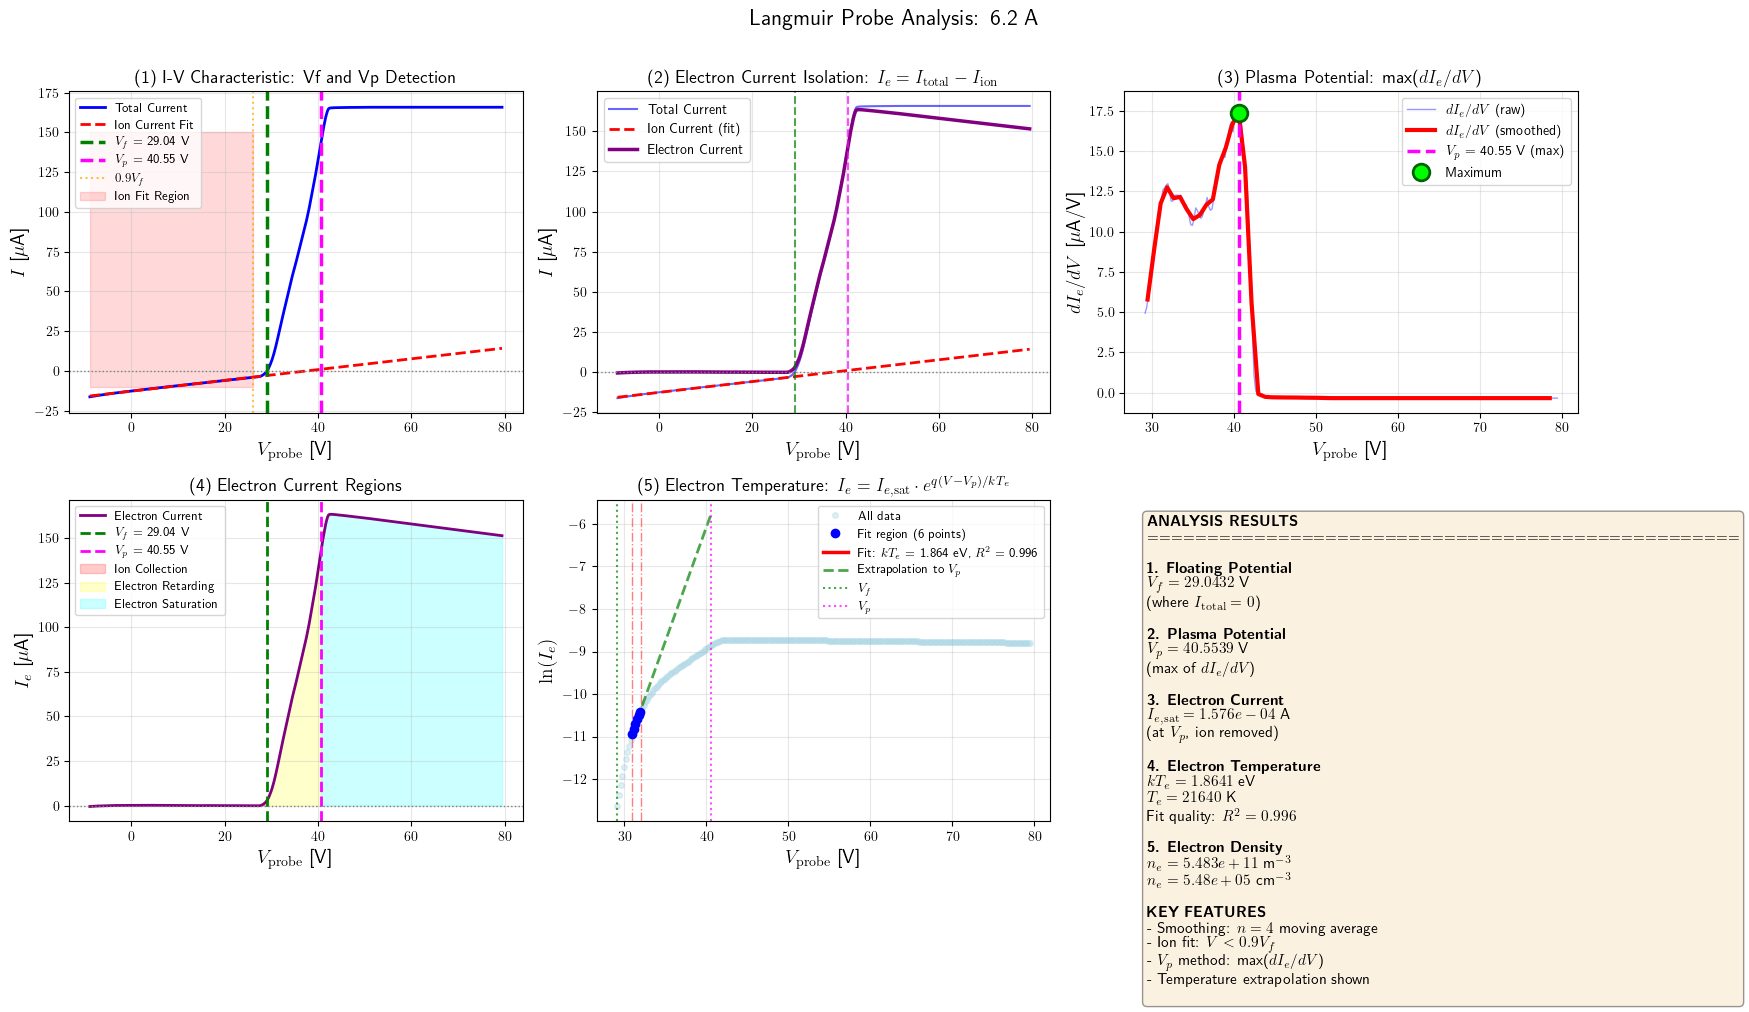

In [5]:

import numpy as np
import matplotlib.pyplot as plt
import scipy.io

plt.rcParams['text.usetex'] = True
plt.close('all')

directory = "./"
name_file = "6.2A.csv"  # Change to your data file

if name_file[-3:] == 'mat':
    vector = scipy.io.loadmat(directory+name_file)
    readnum = vector['readNum']
    Vprobe = readnum[:,1][:int(len(readnum[:,1])/2)]
    Iprobe = readnum[:,2][:int(len(readnum[:,2])/2)]
elif name_file[-3:] == 'csv':
    vector = np.genfromtxt(directory+name_file, delimiter=';',
                          dtype=np.float32, skip_header=50, skip_footer=10, usecols=(0,1))
    Vprobe = vector[:,0]
    Iprobe = vector[:,1]


n = 4  # Number of points to average
Imean = np.zeros(int(len(Iprobe)/n))
Vmean = np.zeros(int(len(Vprobe)/n))

for b in range(int(len(Vprobe)/n)):
    Imean[b] = np.sum(Iprobe[n*b:n*b+n])/n
    Vmean[b] = np.sum(Vprobe[n*b:n*b+n])/n

print(f"Smoothed data points: {len(Vmean)}")

# Use smoothed data
Vprobe = Vmean
Iprobe = Imean


r = 2.5*1e-2      # probe radius, [m]
l = 5*1e-2        # probe length, [m]
me = 9.109*1e-31  # electron mass, [kg]
mi = 6.63*1e-26   # ion mass - Argon, [kg]
q = 1.602*1e-19   # electric charge, [C]
kb = 1.38*1e-23   # boltzmann constant, [J/K]
S = 4*np.pi*r**2  # probe surface area, [m^2]
Ap = S

# Sort by voltage
sort_idx = np.argsort(Vprobe)
V = Vprobe[sort_idx]
I = Iprobe[sort_idx]



zero_crossings = np.where(np.diff(np.sign(I)))[0]

if len(zero_crossings) > 0:
    idx = zero_crossings[0]
    V1, V2 = V[idx], V[idx+1]
    I1, I2 = I[idx], I[idx+1]
    Vf = V1 - I1 * (V2 - V1) / (I2 - I1)
else:
    idx = np.argmin(np.abs(I))
    Vf = V[idx]

print(f">>> Vf = {Vf:.4f} V")


# Ion fit region
ion_region_mask = V < (0.9* Vf)
V_ion = V[ion_region_mask]
I_ion = I[ion_region_mask]

if len(V_ion) > 5:
    coeffs = np.polyfit(V_ion, I_ion, 1)
    slope_ion = coeffs[0]
    intercept_ion = coeffs[1]
    I_ion_fit = slope_ion * V + intercept_ion
    print(f"Ion current fit: I_ion = {slope_ion:.3e}·V + {intercept_ion:.3e}")
else:
    I_ion_fit = np.full_like(V, np.median(I_ion))


Ie = I - I_ion_fit
print(f"Electron current computed: Ie = I_total - I_ion_fit")



# Focus on V > Vf
mask_pos = V > Vf
V_pos = V[mask_pos]
Ie_pos = Ie[mask_pos]

# Derivative
dIe_dV = np.gradient(Ie_pos, V_pos)

# Smooth derivative with n=4
n_smooth = 4
if len(dIe_dV) > n_smooth:
    dIe_dV_smooth = np.zeros(int(len(dIe_dV)/n_smooth))
    V_pos_smooth = np.zeros(int(len(V_pos)/n_smooth))

    for b in range(int(len(dIe_dV)/n_smooth)):
        dIe_dV_smooth[b] = np.sum(dIe_dV[n_smooth*b:n_smooth*b+n_smooth])/n_smooth
        V_pos_smooth[b] = np.sum(V_pos[n_smooth*b:n_smooth*b+n_smooth])/n_smooth

    idx_max = np.argmax(dIe_dV_smooth)
    Vp = V_pos_smooth[idx_max]
else:
    dIe_dV_smooth = dIe_dV
    V_pos_smooth = V_pos
    idx_max = np.argmax(dIe_dV)
    Vp = V_pos[idx_max]

print(f">>> Vp = {Vp:.4f} V")



V_start = 30.9# Start of steep exponential rise
V_end = 32.0    # End of steep rise (just before saturation)

# Apply strict mask - ONLY the steep region
ret_mask = (V >= V_start) & (V <= V_end)
V_ret = V[ret_mask]
Ie_ret = Ie[ret_mask]

# Positive currents only
pos_mask = Ie_ret > 0
V_fit = V_ret[pos_mask]
Ie_fit = Ie_ret[pos_mask]

print(f"Fit region: {V_fit.min():.2f} V to {V_fit.max():.2f} V")
print(f"Number of points: {len(V_fit)}")

if len(V_fit) > 5:
    ln_Ie = np.log(Ie_fit)
    slope, intercept = np.polyfit(V_fit, ln_Ie, 1)

    kTe_J = q / slope
    Te_K = kTe_J / kb
    kTe_eV = kTe_J / q

    # R² calculation
    ln_Ie_pred = slope * V_fit + intercept
    residuals = ln_Ie - ln_Ie_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((ln_Ie - np.mean(ln_Ie))**2)
    r_squared = 1 - (ss_res / ss_tot)

    print(f">>> kTe = {kTe_eV:.4f} eV, Te = {Te_K:.1f} K, R² = {r_squared:.4f}")
    print(f"Slope = {slope:.4f}, Intercept = {intercept:.4f}")

    # Create extrapolation line for visualization
    V_extrap = np.linspace(V_fit.min(), Vp, 100)
    Ie_extrap = np.exp(slope * V_extrap + intercept)
else:
    print("WARNING: Not enough points in fit region!")
    kTe_eV = 0.5
    Te_K = kTe_eV * 11604
    r_squared = 0
    V_extrap = np.array([])
    Ie_extrap = np.array([])





# Correct probe collection area (cylindrical probe)
Ap = 2 * np.pi * r * l   # [m^2]

# 1) Choose a measured saturation current region:
#    V > Vp + ΔV, where Ie is flat (electron saturation)
DeltaV_sat = 3.0  # volts above Vp (adjust if needed)

sat_mask = (V >= Vp + DeltaV_sat) & (Ie > 0)
if np.sum(sat_mask) < 3:
    print("WARNING: Not enough points in measured saturation region, "
          "falling back to extrapolated current.")
    Ie_sat_meas = np.exp(slope * Vp + intercept)
else:
    # Use the mean of Ie in the saturation region
    Ie_sat_meas = np.mean(Ie[sat_mask])
    print(f"Measured saturation region: {V[sat_mask].min():.2f}–{V[sat_mask].max():.2f} V")
    print(f"Average measured Ie_sat = {Ie_sat_meas:.3e} A")

# 2) Use this measured Ie_sat in the density formula
Ie_sat = Ie_sat_meas  # for consistency with later printing

# Electron temperature in Joules (from fit)
kTe_J = kTe_eV * q

# Electron density
ne = (Ie_sat / (q * Ap)) * np.sqrt((2 * np.pi * me) / kTe_J)

print(f">>> Ie_sat (measured) = {Ie_sat:.3e} A")
print(f">>> ne = {ne:.3e} m^-3")
print(f">>> ne = {ne/1e6:.3e} cm^-3")





fig = plt.figure(figsize=(18, 10))

# Create a 2x3 grid
# Plot 1: Main I-V curve with ALL key points marked
ax1 = plt.subplot(2, 3, 1)
ax1.plot(V, I*1e6, 'b-', linewidth=2, label='Total Current')
ax1.plot(V, I_ion_fit*1e6, 'r--', linewidth=2, label='Ion Current Fit')
ax1.axvline(x=Vf, color='green', linestyle='--', linewidth=2.5, label=f'$V_f$ = {Vf:.2f} V')
ax1.axvline(x=Vp, color='magenta', linestyle='--', linewidth=2.5, label=f'$V_p$ = {Vp:.2f} V')
ax1.axvline(x=0.9*Vf, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=r'$0.9 V_f$')
ax1.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax1.fill_between(V[ion_region_mask], -10, 150, alpha=0.15, color='red', label='Ion Fit Region')
ax1.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax1.set_ylabel(r'$I$ [$\mu$A]', fontsize=14)
ax1.set_title('(1) I-V Characteristic: Vf and Vp Detection', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([I.min()*1e6-10, I.max()*1e6+10])

# Plot 2: Electron current isolation
ax2 = plt.subplot(2, 3, 2)
ax2.plot(V, I*1e6, 'b-', linewidth=1.5, alpha=0.6, label='Total Current')
ax2.plot(V, I_ion_fit*1e6, 'r--', linewidth=2, label='Ion Current (fit)')
ax2.plot(V, Ie*1e6, 'purple', linewidth=2.5, label='Electron Current')
ax2.axvline(x=Vf, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axvline(x=Vp, color='magenta', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax2.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax2.set_ylabel(r'$I$ [$\mu$A]', fontsize=14)
ax2.set_title(r'(2) Electron Current Isolation: $I_e = I_{\mathrm{total}} - I_{\mathrm{ion}}$', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: dIe/dV for Vp detection
ax3 = plt.subplot(2, 3, 3)
ax3.plot(V_pos, dIe_dV*1e6, 'b-', alpha=0.4, linewidth=1, label='$dI_e/dV$ (raw)')
ax3.plot(V_pos_smooth, dIe_dV_smooth*1e6, 'r-', linewidth=3, label='$dI_e/dV$ (smoothed)')
ax3.axvline(x=Vp, color='magenta', linestyle='--', linewidth=2.5, label=f'$V_p$ = {Vp:.2f} V (max)')
ax3.plot(Vp, dIe_dV_smooth[idx_max]*1e6, 'go', markersize=12, markeredgewidth=2, 
         markerfacecolor='lime', markeredgecolor='darkgreen', label='Maximum', zorder=5)
ax3.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax3.set_ylabel(r'$dI_e/dV$ [$\mu$A/V]', fontsize=14)
ax3.set_title('(3) Plasma Potential: max($dI_e/dV$)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Electron current with regions marked
ax4 = plt.subplot(2, 3, 4)
ax4.plot(V, Ie*1e6, 'purple', linewidth=2, label='Electron Current')
ax4.axvline(x=Vf, color='green', linestyle='--', linewidth=2, label=f'$V_f$ = {Vf:.2f} V')
ax4.axvline(x=Vp, color='magenta', linestyle='--', linewidth=2, label=f'$V_p$ = {Vp:.2f} V')
# Mark regions
ax4.fill_between(V[V<Vf], 0, Ie[V<Vf]*1e6, alpha=0.2, color='red', label='Ion Collection')
ax4.fill_between(V[(V>=Vf)&(V<=Vp)], 0, Ie[(V>=Vf)&(V<=Vp)]*1e6, alpha=0.2, 
                 color='yellow', label='Electron Retarding')
ax4.fill_between(V[V>Vp], 0, Ie[V>Vp]*1e6, alpha=0.2, color='cyan', label='Electron Saturation')
ax4.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax4.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax4.set_ylabel(r'$I_e$ [$\mu$A]', fontsize=14)
ax4.set_title('(4) Electron Current Regions', fontsize=13, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
# Plot 5: Temperature fit with extrapolation
ax5 = plt.subplot(2, 3, 5)


# **SHOW ALL DATA** (not just fit region)
# Filter for positive electron current across all voltages
mask_all_positive = (V > Vf) & (Ie > 0)
V_all_plot = V[mask_all_positive]
Ie_all_plot = Ie[mask_all_positive]
ln_Ie_all_plot = np.log(Ie_all_plot)
# Plot ALL points in gray/light color
ax5.plot(V_all_plot, ln_Ie_all_plot, 'o', color='lightblue', 
         markersize=4, alpha=0.4, label='All data', zorder=1)

if len(V_fit) > 5:
    # Highlight FIT REGION points in blue
    ax5.plot(V_fit, ln_Ie, 'bo', markersize=6, 
             label=f'Fit region ({len(V_fit)} points)', zorder=3)
    
    # Plot the fit line
    ax5.plot(V_fit, ln_Ie_pred, 'r-', linewidth=2.5, 
             label=f'Fit: $kT_e$ = {kTe_eV:.3f} eV, $R^2$ = {r_squared:.3f}', zorder=2)
    
    # Extrapolation line
    ax5.plot(V_extrap, slope*V_extrap+intercept, 'g--', linewidth=2, 
             alpha=0.7, label='Extrapolation to $V_p$', zorder=1)
    
    ax5.axvline(x=Vf, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label='$V_f$')
    ax5.axvline(x=Vp, color='magenta', linestyle=':', linewidth=1.5, alpha=0.7, label='$V_p$')
    
    # Mark the fit region boundaries
    ax5.axvline(x=V_start, color='red', linestyle='-.', linewidth=1, alpha=0.5)
    ax5.axvline(x=V_end, color='red', linestyle='-.', linewidth=1, alpha=0.5)

ax5.set_xlabel(r'$V_{\mathrm{probe}}$ [V]', fontsize=14)
ax5.set_ylabel(r'$\ln(I_e)$', fontsize=14)
ax5.set_title(r'(5) Electron Temperature: $I_e = I_{e,\mathrm{sat}} \cdot e^{q(V-V_p)/kT_e}$', 
              fontsize=13, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)



# Plot 6: Summary with key results
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

# FIXED: Use raw strings and avoid Python variable interpolation inside LaTeX
summary_text = r"""\textbf{ANALYSIS RESULTS}
""" + f"""{'='*50}

""" + r"""\textbf{1. Floating Potential}
""" + f"""   $V_f = {Vf:.4f}$ V
   (where $I_{{\mathrm{{total}}}} = 0$)

""" + r"""\textbf{2. Plasma Potential}
""" + f"""   $V_p = {Vp:.4f}$ V
   (max of $dI_e/dV$)

""" + r"""\textbf{3. Electron Current}
""" + f"""   $I_{{e,\mathrm{{sat}}}} = {Ie_sat:.3e}$ A
   (at $V_p$, ion removed)

""" + r"""\textbf{4. Electron Temperature}
""" + f"""   $kT_e = {kTe_eV:.4f}$ eV
   $T_e = {Te_K:.0f}$ K
   Fit quality: $R^2 = {r_squared:.3f}$

""" + r"""\textbf{5. Electron Density}
""" + f"""   $n_e = {ne:.3e}$ m$^{{-3}}$
   $n_e = {ne/1e6:.2e}$ cm$^{{-3}}$

""" + r"""\textbf{KEY FEATURES}
""" + f"""- Smoothing: $n=4$ moving average
- Ion fit: $V < 0.9 V_f$
- $V_p$ method: max($dI_e/dV$)
- Temperature extrapolation shown
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.suptitle('Langmuir Probe Analysis: 6.2 A', 
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])

print("\nPlot created successfully!")
print("\nFINAL RESULTS:")
print("="*80)
print(f"1. Vf = {Vf:.4f} V")
print(f"2. Vp = {Vp:.4f} V")
print(f"3. Ie,sat = {Ie_sat:.3e} A")
print(f"4. kTe = {kTe_eV:.4f} eV (Te = {Te_K:.1f} K)")
print(f"5. ne = {ne:.3e} m^-3")
print("="*80)

plt.show()